# Mode Ablation for ML-QRC

This notebook implements the **Mode Ablation** subsection from `ML_QRC-14.pdf`.

It evaluates the full proposed readout `ML-QRC-M` and three ablated variants:

- `No U_T`: temporal factor is frozen
- `No U_n`: qubit factor is frozen
- `No U_F`: observable factor is frozen

The draft states that the frozen factor should be replaced by an **identity-padded map** while the other two factors remain trainable. This notebook implements that directly.

The experiments reuse the cached QRC feature banks from:

- Task 1: Mackey-Glass forecasting
- Task 2: TFIM phase classification

and rerun the readout training over the same 10 seeds used by the main notebooks.


In [1]:
# This cell installs the packages used by the notebook.

%pip install -q numpy pandas matplotlib torch pennylane jupyter


Note: you may need to restart the kernel to use updated packages.


In [2]:
# This cell imports the libraries, resolves the repository root, and
# prepares the artifact directory.

from pathlib import Path
import gc
import os
import random
import time

here = Path.cwd()
if (here / "scripts").exists():
    ROOT = here
elif (here.parent / "scripts").exists():
    ROOT = here.parent
else:
    ROOT = here

cache_root = ROOT / "notebooks" / "artifacts" / "cache"
cache_root.mkdir(parents=True, exist_ok=True)
(cache_root / "mplconfig").mkdir(parents=True, exist_ok=True)

os.environ["XDG_CACHE_HOME"] = str(cache_root.resolve())
os.environ["MPLCONFIGDIR"] = str((cache_root / "mplconfig").resolve())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
import torch
from IPython.display import display

from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams["figure.dpi"] = 1000
plt.rcParams["savefig.dpi"] = 1000
plt.rcParams["figure.figsize"] = (3, 2.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.precision", 6)
torch.set_num_threads(1)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Torch device: {DEVICE}")

ARTIFACT_DIR = ROOT / "notebooks" / "artifacts" / "mode_ablation"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

print(f"Repo root: {ROOT.resolve()}")
print(f"Artifacts: {ARTIFACT_DIR.resolve()}")
print(f"PyTorch: {torch.__version__}")
print(f"PennyLane: {qml.__version__}")


Torch device: cuda
Repo root: /work/vantn/ML-QRC
Artifacts: /work/vantn/ML-QRC/notebooks/artifacts/mode_ablation
PyTorch: 2.6.0+cu124
PennyLane: 0.43.0


## Frozen-Factor Convention

The frozen factor matrices use an **identity-padded map**:

- if `rows <= cols`, the matrix is `[I_rows | 0]`
- if `rows > cols`, the matrix is `[[I_cols], [0]]`

This means the ablated factor is not randomly initialized and not trainable. It simply passes through as much of the original axis as fits into the latent dimension and pads the rest with zeros.

For this notebook:

- Task 1 and Task 2 both use `d = 8`
- `U_T` has shape `(8, 50)`
- `U_n` has shape `(8, 6)`
- `U_F` has shape `(8, 21)`


In [3]:
# This cell stores the experiment configuration and required artifact paths.

CONFIG = {
    "eval_seeds": list(range(10)),
    "d": 8,
    "epochs": 300,
    "batch_size": 32,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "implementation_version": "v2_initmatched_ddof0",
    "task1_num_points": 5000,
    "task1_washout": 1000,
    "task1_train_pool": 3000,
    "task1_test_size": 1000,
    "task1_beta": 0.2,
    "task1_gamma": 0.1,
    "task1_q": 10,
    "task1_tau": 17.0,
    "task1_step": 0.1,
    "task1_x0": 1.2,
    "task2_n_g_values": 16,
    "task2_n_sequences": 200,
    "task2_train_frac": 0.70,
    "task2_data_seed": 42,
}

TASK1_DIR = ROOT / "notebooks" / "artifacts" / "task1_mg_v2"
TASK2_DIR = ROOT / "notebooks" / "artifacts" / "task3_tfim"

TASK1_FEATURES = TASK1_DIR / "qrc_feats_rseed42_p0.01_q6_T50.npy"
TASK1_TABLE = TASK1_DIR / "table2_main.csv"
TASK2_FEATURES = TASK2_DIR / "qrc_feats_tfim_rseed42_p0.01_q6_T50.npy"
TASK2_TABLE = TASK2_DIR / "table_phase.csv"

required = [TASK1_FEATURES, TASK1_TABLE, TASK2_FEATURES, TASK2_TABLE]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required cached artifacts. Run the main Task 1 / Task 2 notebooks first.\n"
        + "\n".join(missing)
    )

T = 50
N_Q = 6
F = 21

display(pd.Series(CONFIG, name="value"))
print("Required artifacts found.")


eval_seeds                [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
d                                                      8
epochs                                               300
batch_size                                            32
lr                                                 0.001
weight_decay                                     0.00001
implementation_version              v2_initmatched_ddof0
task1_num_points                                    5000
task1_washout                                       1000
task1_train_pool                                    3000
task1_test_size                                     1000
task1_beta                                           0.2
task1_gamma                                          0.1
task1_q                                               10
task1_tau                                           17.0
task1_step                                           0.1
task1_x0                                             1.2
task2_n_g_values               

Required artifacts found.


In [4]:
# This cell reconstructs the Mackey-Glass targets and split exactly
# as in the main Task 1 notebook.

def generate_mackey_glass(num_points, beta, gamma, q, tau, step, x0):
    delay = int(round(tau / step))
    total = delay + num_points
    x = np.full(total + 1, x0, dtype=np.float64)

    def rhs(x_now, x_delay):
        return beta * x_delay / (1.0 + x_delay ** q) - gamma * x_now

    for k in range(delay, total):
        x_now = x[k]
        x_d0 = x[k - delay]
        x_dh = 0.5 * (x[k - delay] + x[k - delay + 1])
        x_d1 = x[k - delay + 1]
        k1 = rhs(x_now, x_d0)
        k2 = rhs(x_now + 0.5 * step * k1, x_dh)
        k3 = rhs(x_now + 0.5 * step * k2, x_dh)
        k4 = rhs(x_now + step * k3, x_d1)
        x[k + 1] = x_now + (step / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    return x[delay + 1 : delay + 1 + num_points].astype(np.float32)

task1_series = generate_mackey_glass(
    CONFIG["task1_num_points"],
    CONFIG["task1_beta"],
    CONFIG["task1_gamma"],
    CONFIG["task1_q"],
    CONFIG["task1_tau"],
    CONFIG["task1_step"],
    CONFIG["task1_x0"],
)

W = CONFIG["task1_washout"]
TR = CONFIG["task1_train_pool"]
TE = CONFIG["task1_test_size"]

task1_scale_min = float(task1_series[W:W + TR].min())
task1_scale_range = float(task1_series[W:W + TR].max() - task1_series[W:W + TR].min())
task1_series_scaled = ((task1_series - task1_scale_min) / task1_scale_range).astype(np.float32)

def unscale_task1(values):
    return (np.asarray(values, dtype=np.float64) * task1_scale_range + task1_scale_min).astype(np.float32)

task1_decision_times = np.arange(T, len(task1_series), dtype=np.int32)
task1_targets_scaled = task1_series_scaled[task1_decision_times].astype(np.float32)
task1_targets_original = task1_series[task1_decision_times].astype(np.float32)
task1_train_positions = np.where((task1_decision_times >= W) & (task1_decision_times < W + TR))[0]
task1_test_positions = np.where((task1_decision_times >= W + TR) & (task1_decision_times < W + TR + TE))[0]

task1_qrc = np.load(TASK1_FEATURES, mmap_mode="r")
print(f"Task 1 feature bank: {task1_qrc.shape}")


Task 1 feature bank: (4950, 50, 6, 21)


In [5]:
# This cell reconstructs the TFIM labels and split exactly as in the
# main Task 2 notebook.

task2_g_values = np.linspace(0.2, 1.8, CONFIG["task2_n_g_values"])
task2_g_labels = np.array([0 if g < 1 else 1 for g in task2_g_values], dtype=np.int64)
task2_all_labels = np.repeat(task2_g_labels, CONFIG["task2_n_sequences"])

rng_split = np.random.default_rng(CONFIG["task2_data_seed"] + 1)
task2_train_idx = []
task2_test_idx = []
for gi in range(CONFIG["task2_n_g_values"]):
    start = gi * CONFIG["task2_n_sequences"]
    idx = np.arange(start, start + CONFIG["task2_n_sequences"])
    rng_split.shuffle(idx)
    n_tr = round(CONFIG["task2_n_sequences"] * CONFIG["task2_train_frac"])
    task2_train_idx.extend(idx[:n_tr])
    task2_test_idx.extend(idx[n_tr:])

task2_train_idx = np.array(task2_train_idx, dtype=np.int64)
task2_test_idx = np.array(task2_test_idx, dtype=np.int64)

task2_y_train = task2_all_labels[task2_train_idx]
task2_y_test = task2_all_labels[task2_test_idx]

task2_qrc_all = np.load(TASK2_FEATURES, mmap_mode="r")
task2_train_qrc = task2_qrc_all[task2_train_idx]
task2_test_qrc = task2_qrc_all[task2_test_idx]

print(f"Task 2 train/test feature banks: {task2_train_qrc.shape} / {task2_test_qrc.shape}")


Task 2 train/test feature banks: (2240, 50, 6, 21) / (960, 50, 6, 21)


In [6]:
# This cell defines the common helpers and the ablated ML-QRC model.

def nmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

def accuracy(y_true, y_pred):
    return 100.0 * float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))

class Standardizer:
    def fit(self, X):
        flat = X.reshape(X.shape[0], -1).astype(np.float64)
        self.mu = flat.mean(axis=0)
        self.sig = flat.std(axis=0)
        self.sig[self.sig < 1e-8] = 1.0
        return self

    def transform(self, X):
        shape = X.shape
        flat = X.reshape(shape[0], -1).astype(np.float64)
        flat = (flat - self.mu) / self.sig
        return flat.reshape(shape).astype(np.float32)

def identity_padded(rows: int, cols: int) -> torch.Tensor:
    matrix = torch.zeros(rows, cols, dtype=torch.float32)
    overlap = min(rows, cols)
    matrix[:overlap, :overlap] = torch.eye(overlap, dtype=torch.float32)
    return matrix

class ModeAblatedMLQRC(nn.Module):
    def __init__(self, time_steps: int, n_qubits: int, f_dim: int, d: int, freeze_mode: str | None = None):
        super().__init__()

        u_t_init = torch.randn(d, time_steps) * 0.05
        u_n_init = torch.randn(d, n_qubits) * 0.05
        u_f_init = torch.randn(d, f_dim) * 0.05

        if freeze_mode == "time":
            self.register_buffer("u_t_fixed", identity_padded(d, time_steps))
            self.u_t = None
        else:
            self.u_t_fixed = None
            self.u_t = nn.Parameter(u_t_init)

        if freeze_mode == "qubit":
            self.register_buffer("u_n_fixed", identity_padded(d, n_qubits))
            self.u_n = None
        else:
            self.u_n_fixed = None
            self.u_n = nn.Parameter(u_n_init)

        if freeze_mode == "observable":
            self.register_buffer("u_f_fixed", identity_padded(d, f_dim))
            self.u_f = None
        else:
            self.u_f_fixed = None
            self.u_f = nn.Parameter(u_f_init)

        self.head = nn.Linear(d * d * d, 1)

    def get_u_t(self):
        return self.u_t if self.u_t is not None else self.u_t_fixed

    def get_u_n(self):
        return self.u_n if self.u_n is not None else self.u_n_fixed

    def get_u_f(self):
        return self.u_f if self.u_f is not None else self.u_f_fixed

    def forward(self, x):
        y = torch.einsum("btnf,dt->bdnf", x, self.get_u_t())
        y = torch.einsum("bdnf,in->bdif", y, self.get_u_n())
        y = torch.einsum("bdif,jf->bdij", y, self.get_u_f())
        return self.head(y.reshape(y.shape[0], -1)).squeeze(-1)

def count_params(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

def train_regression(model, Xtr, ytr):
    model = model.to(DEVICE)
    dataset = TensorDataset(
        torch.tensor(Xtr, dtype=torch.float32),
        torch.tensor(ytr, dtype=torch.float32),
    )
    loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )
    loss_function = nn.MSELoss()
    model.train()

    for _ in range(CONFIG["epochs"]):
        for batch_features, batch_targets in loader:
            batch_features = batch_features.to(DEVICE)
            batch_targets = batch_targets.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(batch_features)
            loss = loss_function(predictions, batch_targets)
            loss.backward()
            optimizer.step()

    return model

def train_binary(model, Xtr, ytr):
    model = model.to(DEVICE)
    dataset = TensorDataset(
        torch.tensor(Xtr, dtype=torch.float32),
        torch.tensor(ytr.astype(np.float32), dtype=torch.float32),
    )
    loader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=True)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"],
    )
    loss_function = nn.BCEWithLogitsLoss()
    model.train()

    for _ in range(CONFIG["epochs"]):
        for batch_features, batch_targets in loader:
            batch_features = batch_features.to(DEVICE)
            batch_targets = batch_targets.to(DEVICE)
            optimizer.zero_grad()
            logits = model(batch_features)
            loss = loss_function(logits, batch_targets)
            loss.backward()
            optimizer.step()

    return model

@torch.no_grad()
def predict_regression(model, X):
    model.eval()
    tensor_features = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    return model(tensor_features).cpu().numpy().astype(np.float32)

@torch.no_grad()
def predict_binary(model, X):
    model.eval()
    tensor_features = torch.tensor(X, dtype=torch.float32, device=DEVICE)
    logits = model(tensor_features).cpu().numpy()
    return (logits >= 0.0).astype(np.int64)

def cache_is_current(raw_df: pd.DataFrame) -> bool:
    return (
        "implementation_version" in raw_df.columns
        and set(raw_df["implementation_version"].dropna().unique()) == {CONFIG["implementation_version"]}
    )

def summarize_task1_raw(raw_df: pd.DataFrame) -> pd.DataFrame:
    return (
        raw_df.groupby("ablation", sort=False)["nmse"]
        .agg(nmse_mean="mean", nmse_std=lambda values: float(np.std(values, ddof=0)))
        .reset_index()
    )

def summarize_task2_raw(raw_df: pd.DataFrame) -> pd.DataFrame:
    return (
        raw_df.groupby("ablation", sort=False)["accuracy"]
        .agg(acc_mean="mean", acc_std=lambda values: float(np.std(values, ddof=0)))
        .reset_index()
    )

ABLATIONS = [
    {"label": "Full ML-QRC", "freeze_mode": None},
    {"label": "No U_T", "freeze_mode": "time"},
    {"label": "No U_n", "freeze_mode": "qubit"},
    {"label": "No U_F", "freeze_mode": "observable"},
]

print("Helpers ready.")
for spec in ABLATIONS:
    model = ModeAblatedMLQRC(T, N_Q, F, CONFIG["d"], spec["freeze_mode"])
    print(f"  {spec['label']:<12s} params = {count_params(model):,}")
    del model


Helpers ready.
  Full ML-QRC  params = 1,129
  No U_T       params = 729
  No U_n       params = 1,081
  No U_F       params = 961


In [7]:
# This cell runs the Task 1 full-data mode ablation over the same
# 10 seeds used by the main notebook.
#
# If the raw CSV exists and matches the current implementation version,
# we load it and recompute the summary. Otherwise we retrain.

task1_raw_csv = ARTIFACT_DIR / "task1_mode_ablation_raw.csv"
task1_summary_csv = ARTIFACT_DIR / "task1_mode_ablation_summary.csv"

task1_raw = pd.read_csv(task1_raw_csv) if task1_raw_csv.exists() else None

if task1_raw is not None and cache_is_current(task1_raw):
    print(f"Loading cached Task 1 mode ablation: {task1_raw_csv.name}")
else:
    if task1_raw is not None:
        print("Ignoring stale Task 1 mode ablation cache; recomputing.")
    task1_train_subset = task1_train_positions
    task1_scaler = Standardizer().fit(task1_qrc[task1_train_subset])
    task1_Xtr = task1_scaler.transform(task1_qrc[task1_train_subset])
    task1_Xte = task1_scaler.transform(task1_qrc[task1_test_positions])
    task1_ytr = task1_targets_scaled[task1_train_subset]
    task1_yte = task1_targets_original[task1_test_positions]

    task1_rows = []

    for seed in CONFIG["eval_seeds"]:
        for spec in ABLATIONS:
            set_seed(seed)
            model = ModeAblatedMLQRC(T, N_Q, F, CONFIG["d"], spec["freeze_mode"])
            model = train_regression(model, task1_Xtr, task1_ytr)
            predictions = unscale_task1(predict_regression(model, task1_Xte))
            score = nmse(task1_yte, predictions)
            task1_rows.append(
                {
                    "seed": seed,
                    "ablation": spec["label"],
                    "freeze_mode": spec["freeze_mode"] if spec["freeze_mode"] is not None else "none",
                    "nmse": score,
                    "implementation_version": CONFIG["implementation_version"],
                }
            )
            del model, predictions
            gc.collect()

        print(f"  Task 1 seed={seed} complete")

    task1_raw = pd.DataFrame(task1_rows)

task1_summary = summarize_task1_raw(task1_raw)
task1_full_mean = float(task1_summary.loc[task1_summary["ablation"] == "Full ML-QRC", "nmse_mean"].iloc[0])
task1_summary["drop_vs_full"] = task1_summary["nmse_mean"] - task1_full_mean

display(task1_summary)


Loading cached Task 1 mode ablation: task1_mode_ablation_raw.csv


,ablation,nmse_mean,nmse_std,drop_vs_full
0,Full ML-QRC,0.010527,0.002642,0.000000
1,No U_T,0.058787,0.006124,0.048260
2,No U_n,0.010515,0.001444,-0.000012
3,No U_F,0.014587,0.000914,0.004060


In [8]:
# This cell runs the Task 2 full-data mode ablation over the same
# 10 seeds used by the main notebook.
#
# If the raw CSV exists and matches the current implementation version,
# we load it and recompute the summary. Otherwise we retrain.

task2_raw_csv = ARTIFACT_DIR / "task2_mode_ablation_raw.csv"
task2_summary_csv = ARTIFACT_DIR / "task2_mode_ablation_summary.csv"

task2_raw = pd.read_csv(task2_raw_csv) if task2_raw_csv.exists() else None

if task2_raw is not None and cache_is_current(task2_raw):
    print(f"Loading cached Task 2 mode ablation: {task2_raw_csv.name}")
else:
    if task2_raw is not None:
        print("Ignoring stale Task 2 mode ablation cache; recomputing.")
    task2_train_subset = np.arange(len(task2_y_train), dtype=np.int64)
    task2_scaler = Standardizer().fit(task2_train_qrc[task2_train_subset])
    task2_Xtr = task2_scaler.transform(task2_train_qrc[task2_train_subset])
    task2_Xte = task2_scaler.transform(task2_test_qrc)
    task2_ytr = task2_y_train[task2_train_subset]
    task2_yte = task2_y_test

    task2_rows = []

    for seed in CONFIG["eval_seeds"]:
        for spec in ABLATIONS:
            set_seed(seed)
            model = ModeAblatedMLQRC(T, N_Q, F, CONFIG["d"], spec["freeze_mode"])
            model = train_binary(model, task2_Xtr, task2_ytr)
            predictions = predict_binary(model, task2_Xte)
            score = accuracy(task2_yte, predictions)
            task2_rows.append(
                {
                    "seed": seed,
                    "ablation": spec["label"],
                    "freeze_mode": spec["freeze_mode"] if spec["freeze_mode"] is not None else "none",
                    "accuracy": score,
                    "implementation_version": CONFIG["implementation_version"],
                }
            )
            del model, predictions
            gc.collect()

        print(f"  Task 2 seed={seed} complete")

    task2_raw = pd.DataFrame(task2_rows)

task2_summary = summarize_task2_raw(task2_raw)
task2_full_mean = float(task2_summary.loc[task2_summary["ablation"] == "Full ML-QRC", "acc_mean"].iloc[0])
task2_summary["drop_vs_full"] = task2_full_mean - task2_summary["acc_mean"]

display(task2_summary)


Loading cached Task 2 mode ablation: task2_mode_ablation_raw.csv


,ablation,acc_mean,acc_std,drop_vs_full
0,Full ML-QRC,66.572917,1.136754,0.000000
1,No U_T,71.614583,0.149144,-5.041667
2,No U_n,66.604166,0.877971,-0.031250
3,No U_F,66.791667,0.217506,-0.218750


In [9]:
# This cell compares the full-model rows against the main notebooks
# to make sure the rerun is numerically aligned.

task1_reference = pd.read_csv(TASK1_TABLE)
task2_reference = pd.read_csv(TASK2_TABLE)

task1_ref_full = float(task1_reference.loc[task1_reference["raw_key"] == "ML-QRC-M", "full_mean"].iloc[0])
task2_ref_full = float(task2_reference.loc[task2_reference["Method"] == "ML-QRC (ours)", "full_mean"].iloc[0])
task1_ref_std = float(task1_reference.loc[task1_reference["raw_key"] == "ML-QRC-M", "full_std"].iloc[0])
task2_ref_std = float(task2_reference.loc[task2_reference["Method"] == "ML-QRC (ours)", "full_std"].iloc[0])

consistency = pd.DataFrame(
    [
        {
            "Task": "Task 1",
            "Reference full ML-QRC": task1_ref_full,
            "Mode ablation full ML-QRC": task1_full_mean,
            "Reference std": task1_ref_std,
            "Mode ablation std": float(task1_summary.loc[task1_summary["ablation"] == "Full ML-QRC", "nmse_std"].iloc[0]),
        },
        {
            "Task": "Task 2",
            "Reference full ML-QRC": task2_ref_full,
            "Mode ablation full ML-QRC": task2_full_mean,
            "Reference std": task2_ref_std,
            "Mode ablation std": float(task2_summary.loc[task2_summary["ablation"] == "Full ML-QRC", "acc_std"].iloc[0]),
        },
    ]
)
consistency["abs_mean_diff"] = (consistency["Reference full ML-QRC"] - consistency["Mode ablation full ML-QRC"]).abs()
consistency["abs_std_diff"] = (consistency["Reference std"] - consistency["Mode ablation std"]).abs()
display(consistency)

if (consistency["abs_mean_diff"] > 5e-6).any() or (consistency["abs_std_diff"] > 5e-6).any():
    raise AssertionError("Mode-ablation full-model rows do not match the main Task 1/Task 2 tables.")


,Task,Reference full ML-QRC,Mode ablation full ML-QRC,Reference std,Mode ablation std,abs_mean_diff,abs_std_diff
0,Task 1,0.010527,0.010527,0.002643,0.002642,1.000000e-07,5.226983e-07
1,Task 2,66.572917,66.572917,1.136754,1.136754,2.000000e-07,2.014090e-07


In [10]:
# This cell builds the draft-ready Table VI.
#
# Signed deltas are relative to the full model.
# Positive means the ablation worsened performance; negative means it improved.

order = ["Full ML-QRC", "No U_T", "No U_n", "No U_F"]
task1_summary["ablation"] = pd.Categorical(task1_summary["ablation"], categories=order, ordered=True)
task2_summary["ablation"] = pd.Categorical(task2_summary["ablation"], categories=order, ordered=True)
task1_summary = task1_summary.sort_values("ablation").reset_index(drop=True)
task2_summary = task2_summary.sort_values("ablation").reset_index(drop=True)

mode_table = pd.DataFrame(
    {
        "Ablation": order,
        "Task1_NMSE": task1_summary["nmse_mean"].to_numpy(),
        "Task1_STD": task1_summary["nmse_std"].to_numpy(),
        "Task1_Drop": task1_summary["drop_vs_full"].to_numpy(),
        "Task2_Acc": task2_summary["acc_mean"].to_numpy(),
        "Task2_STD": task2_summary["acc_std"].to_numpy(),
        "Task2_Drop": task2_summary["drop_vs_full"].to_numpy(),
    }
)

display(mode_table)

mode_table_csv = ARTIFACT_DIR / "table_mode_ablation.csv"
task1_raw_csv = ARTIFACT_DIR / "task1_mode_ablation_raw.csv"
task2_raw_csv = ARTIFACT_DIR / "task2_mode_ablation_raw.csv"
task1_summary_csv = ARTIFACT_DIR / "task1_mode_ablation_summary.csv"
task2_summary_csv = ARTIFACT_DIR / "task2_mode_ablation_summary.csv"

mode_table.to_csv(mode_table_csv, index=False, float_format="%.6f")
task1_raw.to_csv(task1_raw_csv, index=False, float_format="%.6f")
task2_raw.to_csv(task2_raw_csv, index=False, float_format="%.6f")
task1_summary.to_csv(task1_summary_csv, index=False, float_format="%.6f")
task2_summary.to_csv(task2_summary_csv, index=False, float_format="%.6f")

print("=" * 92)
print(" TABLE VI  Mode ablation  (positive delta means the ablation worsened performance)")
print("=" * 92)
print(f"  {'Ablation':<16} {'Task 1 NMSE':>22}  {'Delta':>10}   {'Task 2 Acc':>18}  {'Delta':>10}")
print("-" * 92)
for _, row in mode_table.iterrows():
    task1_drop = "—" if row["Ablation"] == "Full ML-QRC" else f"{row['Task1_Drop']:.4f}"
    task2_drop = "—" if row["Ablation"] == "Full ML-QRC" else f"{row['Task2_Drop']:.2f}"
    print(
        f"  {row['Ablation']:<16} "
        f"{row['Task1_NMSE']:.4f} ± {row['Task1_STD']:.4f}  "
        f"{task1_drop:>10}   "
        f"{row['Task2_Acc']:.2f} ± {row['Task2_STD']:.2f}  "
        f"{task2_drop:>10}"
    )
print("=" * 92)

print("\nLaTeX rows:")
for _, row in mode_table.iterrows():
    task1_drop = "—" if row["Ablation"] == "Full ML-QRC" else f"{row['Task1_Drop']:.4f}"
    task2_drop = "—" if row["Ablation"] == "Full ML-QRC" else f"{row['Task2_Drop']:.2f}"
    print(
        f"    {row['Ablation']} & {row['Task1_NMSE']:.4f}\\pm{row['Task1_STD']:.4f} & {task1_drop} & "
        f"{row['Task2_Acc']:.1f}\\pm{row['Task2_STD']:.1f} & {task2_drop} \\\\"
    )

print(f"Saved: {mode_table_csv.resolve()}")


,Ablation,Task1_NMSE,Task1_STD,Task1_Drop,Task2_Acc,Task2_STD,Task2_Drop
0,Full ML-QRC,0.010527,0.002642,0.000000,66.572917,1.136754,0.000000
1,No U_T,0.058787,0.006124,0.048260,71.614583,0.149144,-5.041667
2,No U_n,0.010515,0.001444,-0.000012,66.604166,0.877971,-0.031250
3,No U_F,0.014587,0.000914,0.004060,66.791667,0.217506,-0.218750


 TABLE VI  Mode ablation  (positive delta means the ablation worsened performance)
  Ablation                    Task 1 NMSE       Delta           Task 2 Acc       Delta
--------------------------------------------------------------------------------------------
  Full ML-QRC      0.0105 ± 0.0026           —   66.57 ± 1.14           —
  No U_T           0.0588 ± 0.0061      0.0483   71.61 ± 0.15       -5.04
  No U_n           0.0105 ± 0.0014     -0.0000   66.60 ± 0.88       -0.03
  No U_F           0.0146 ± 0.0009      0.0041   66.79 ± 0.22       -0.22

LaTeX rows:
    Full ML-QRC & 0.0105\pm0.0026 & — & 66.6\pm1.1 & — \\
    No U_T & 0.0588\pm0.0061 & 0.0483 & 71.6\pm0.1 & -5.04 \\
    No U_n & 0.0105\pm0.0014 & -0.0000 & 66.6\pm0.9 & -0.03 \\
    No U_F & 0.0146\pm0.0009 & 0.0041 & 66.8\pm0.2 & -0.22 \\
Saved: /work/vantn/ML-QRC/notebooks/artifacts/mode_ablation/table_mode_ablation.csv


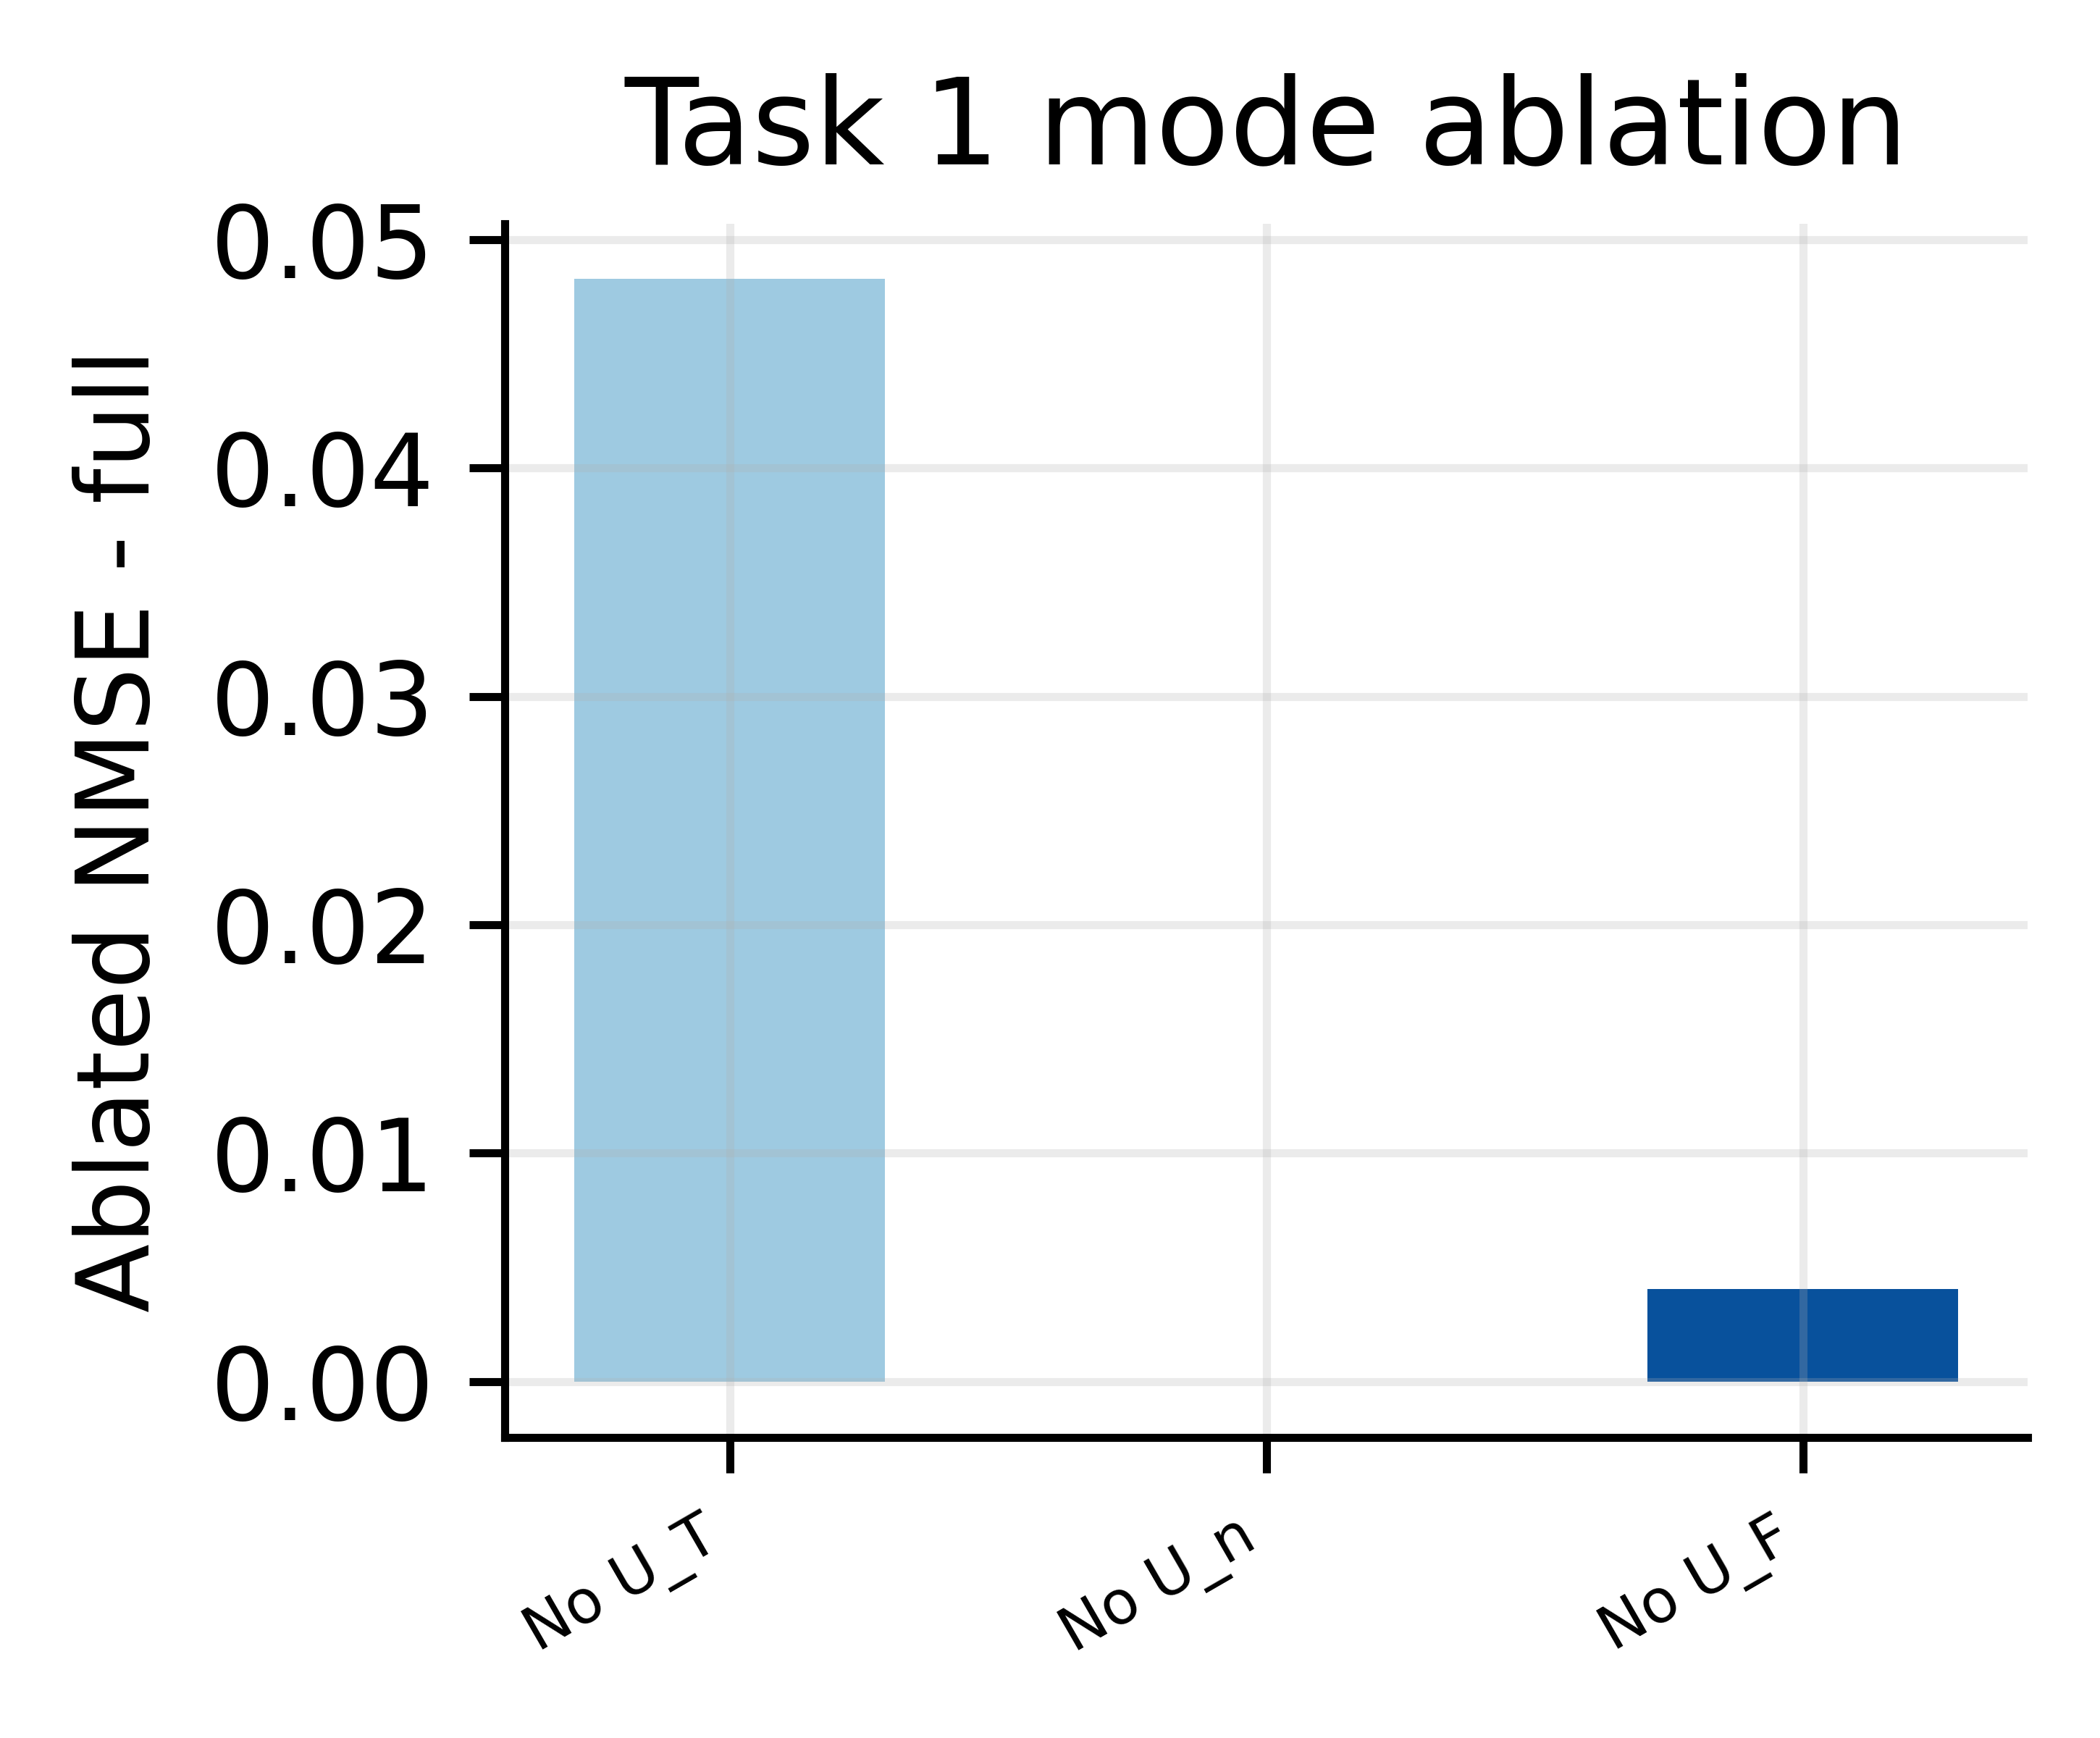

Saved: fig_mode_ablation_task1.pdf


In [11]:
# This cell creates a compact Task 1 drop figure.

task1_plot = task1_summary.copy()
task1_plot = task1_plot.loc[task1_plot["ablation"] != "Full ML-QRC"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3, 2.5), dpi=1000)
x = np.arange(len(task1_plot))
ax.bar(x, task1_plot["drop_vs_full"], width=0.58, color=["#9ecae1", "#3182bd", "#08519c"])
ax.set_xticks(x)
ax.set_xticklabels(task1_plot["ablation"], rotation=30, ha="right", fontsize=6)
ax.set_ylabel("Ablated NMSE - full")
ax.set_title("Task 1 mode ablation")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_mode_ablation_task1.pdf", bbox_inches="tight")
plt.savefig(ARTIFACT_DIR / "fig_mode_ablation_task1.png", bbox_inches="tight")
plt.show()
print("Saved: fig_mode_ablation_task1.pdf")


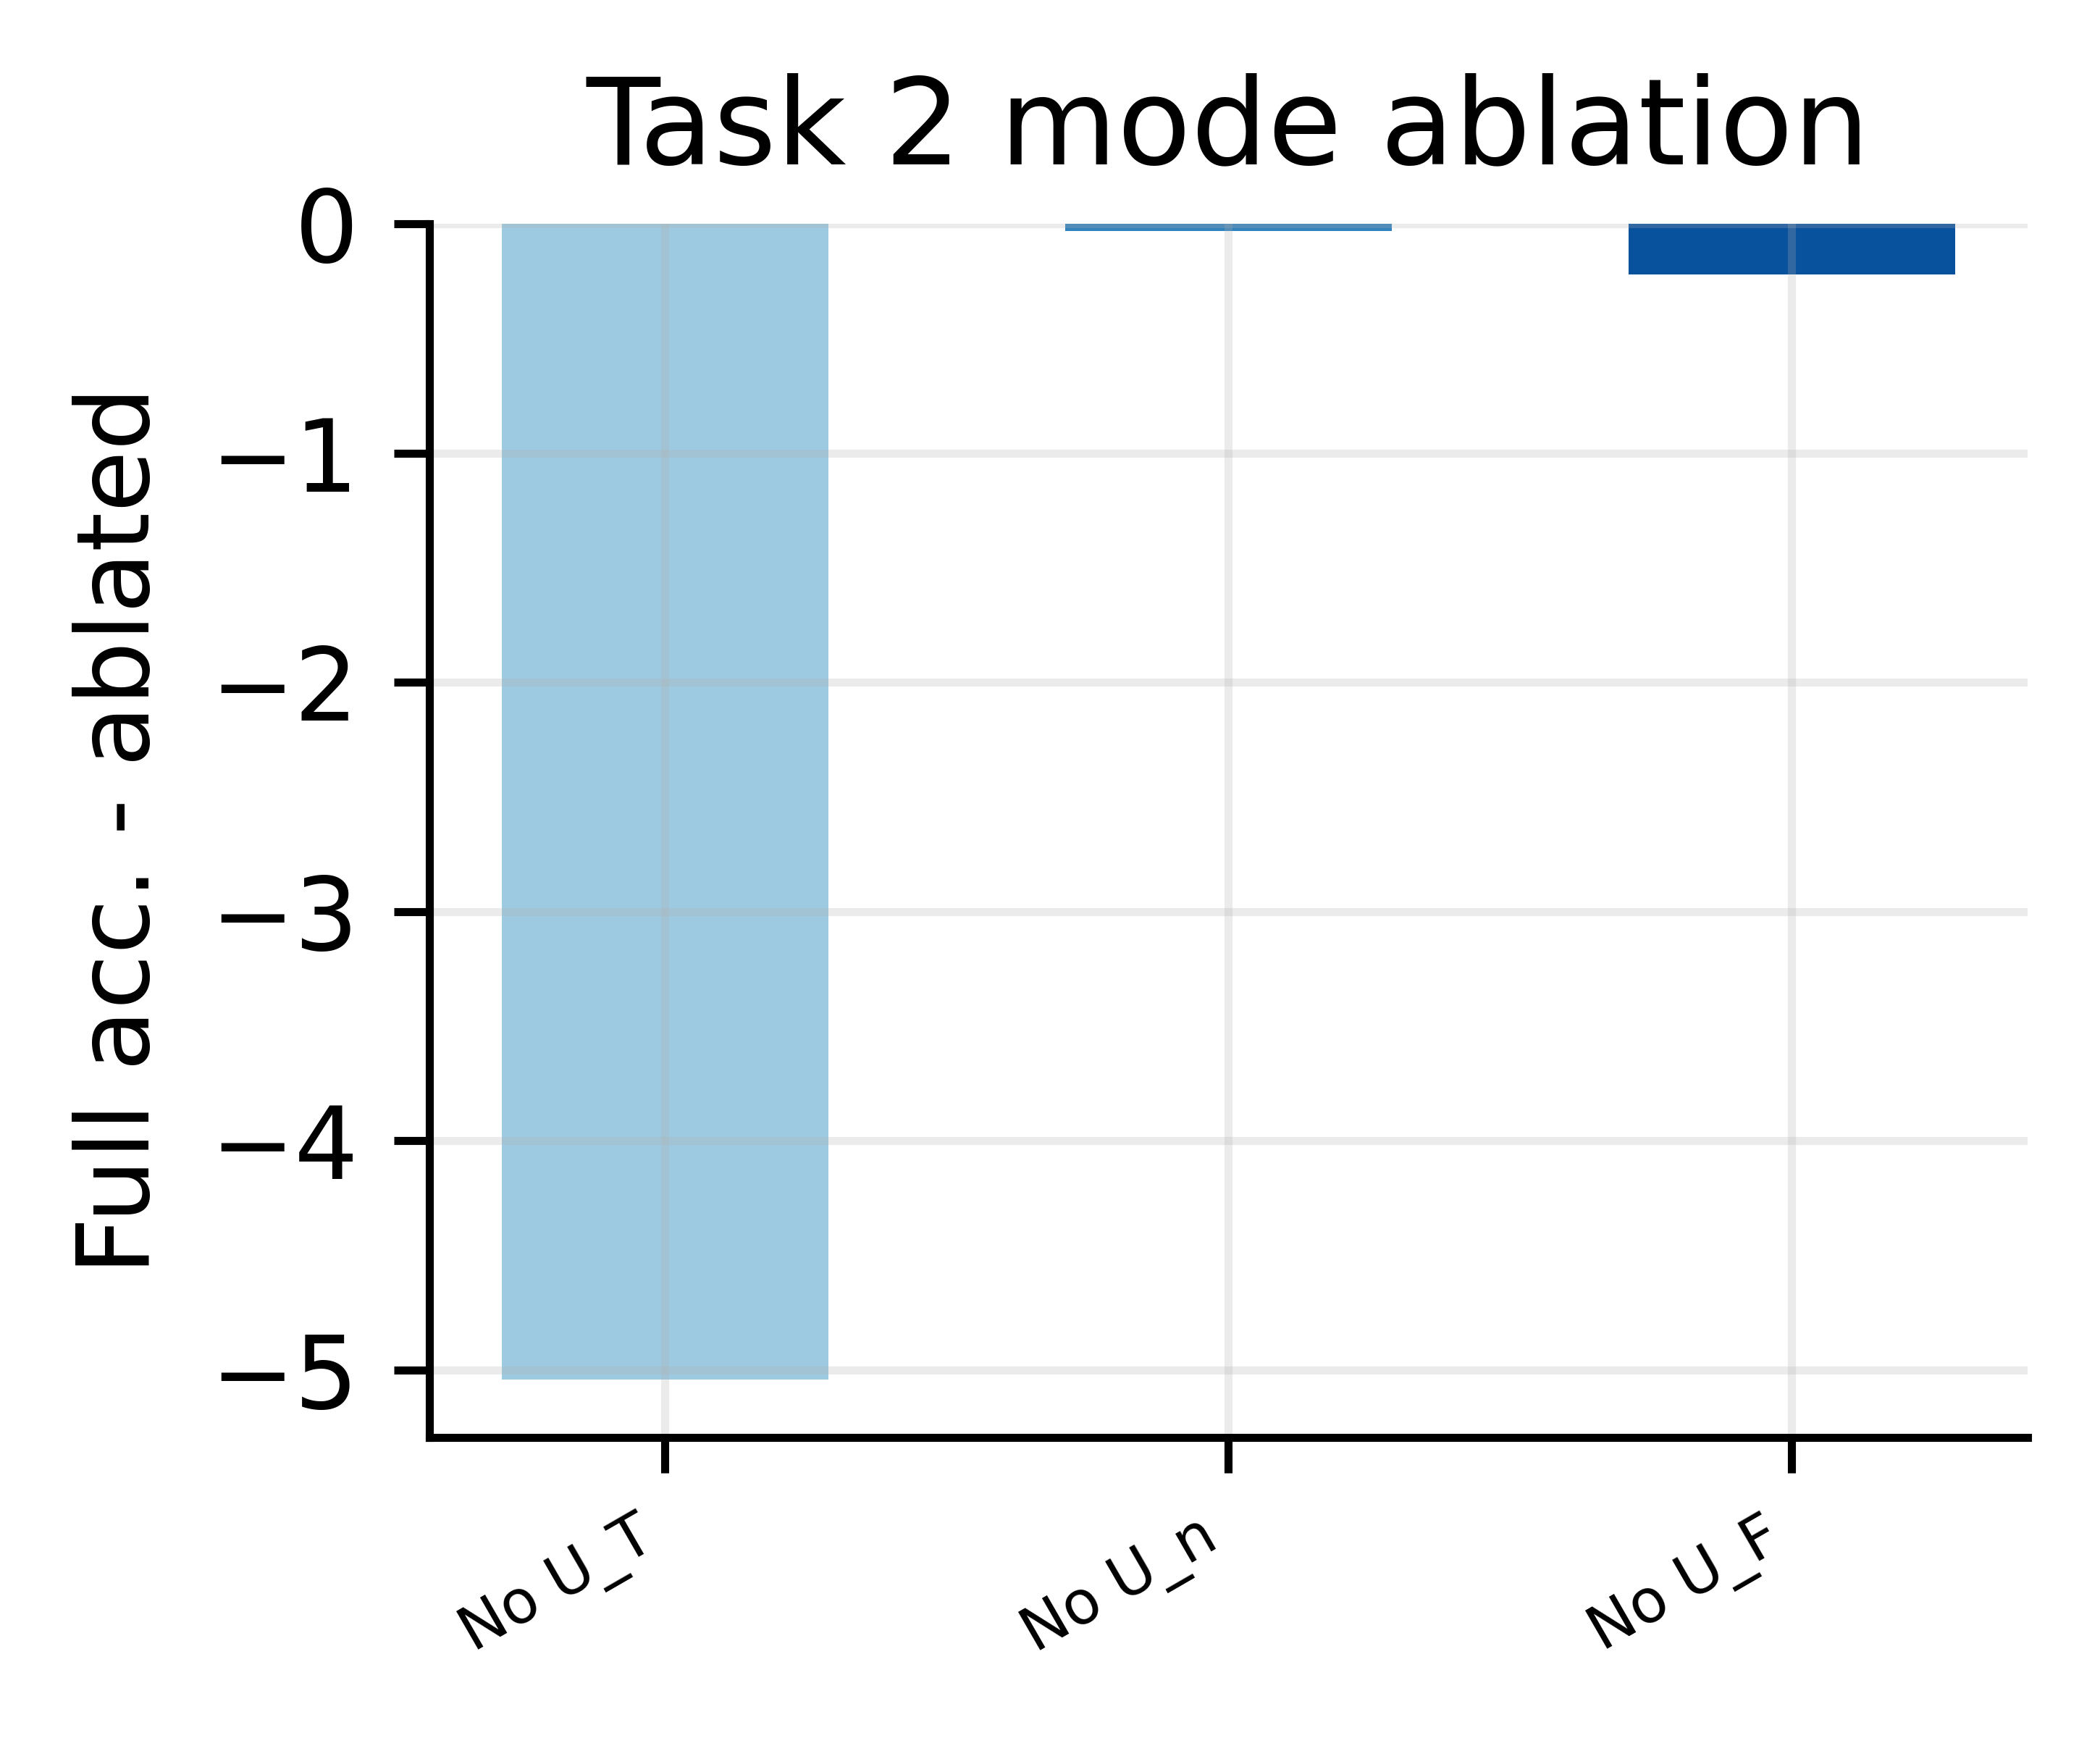

Saved: fig_mode_ablation_task2.pdf


In [12]:
# This cell creates a compact Task 2 drop figure.

task2_plot = task2_summary.copy()
task2_plot = task2_plot.loc[task2_plot["ablation"] != "Full ML-QRC"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3, 2.5), dpi=1000)
x = np.arange(len(task2_plot))
ax.bar(x, task2_plot["drop_vs_full"], width=0.58, color=["#9ecae1", "#3182bd", "#08519c"])
ax.set_xticks(x)
ax.set_xticklabels(task2_plot["ablation"], rotation=30, ha="right", fontsize=6)
ax.set_ylabel("Full acc. - ablated")
ax.set_title("Task 2 mode ablation")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "fig_mode_ablation_task2.pdf", bbox_inches="tight")
plt.savefig(ARTIFACT_DIR / "fig_mode_ablation_task2.png", bbox_inches="tight")
plt.show()
print("Saved: fig_mode_ablation_task2.pdf")


## Summary

This notebook implements the **Mode Ablation** experiment from the current draft.

It trains:

- the full `ML-QRC-M`,
- `No U_T`,
- `No U_n`,
- `No U_F`,

on:

- Task 1 full-data Mackey-Glass,
- Task 2 full-data TFIM,

using matched initialization for all non-frozen factors. The reported deltas are signed relative to the full model: positive means the ablation worsened performance, while negative means the ablated variant improved.

It saves the draft-ready outputs:

- `table_mode_ablation.csv`
- `task1_mode_ablation_raw.csv`
- `task1_mode_ablation_summary.csv`
- `task2_mode_ablation_raw.csv`
- `task2_mode_ablation_summary.csv`
- `fig_mode_ablation_task1.pdf`
- `fig_mode_ablation_task2.pdf`
